# House Grouping System — K-Means

Classify California census block groups by region and median income using K-Means clustering, then train a supervised classifier on the resulting cluster labels.

## Step 1: Load the Dataset

In [8]:
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

url = "https://breathecode.herokuapp.com/asset/internal-link?id=439&path=housing.csv"
local_path = "../data/raw/housing.csv"

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
else:
    df = pd.read_csv(url)
    os.makedirs("../data/raw", exist_ok=True)
    df.to_csv(local_path, index=False)

df = df[["Latitude", "Longitude", "MedInc"]]
df.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


### Split into train and test

In [9]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {train_set.shape}, Test: {test_set.shape}")
train_set.head()

Train: (16512, 3), Test: (4128, 3)


,Latitude,Longitude,MedInc
14196,32.71,-117.03,3.2596
8267,33.77,-118.16,3.8125
17445,34.66,-120.48,4.1563
14265,32.69,-117.11,1.9425
2271,36.78,-119.80,3.5542


## Step 2: Build a K-Means Model

Cluster into **6** groups using `Latitude`, `Longitude`, and `MedInc`.

In [10]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
kmeans.fit(train_set)

train_set = train_set.copy()
train_set["cluster"] = kmeans.labels_.astype(str)
train_set["cluster"].value_counts().sort_index()

/Users/match/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/match/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/match/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/match/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/match/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/match/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_s

cluster
0    2455
1    3807
2    1280
3    4368
4     246
5    4356
Name: count, dtype: int64

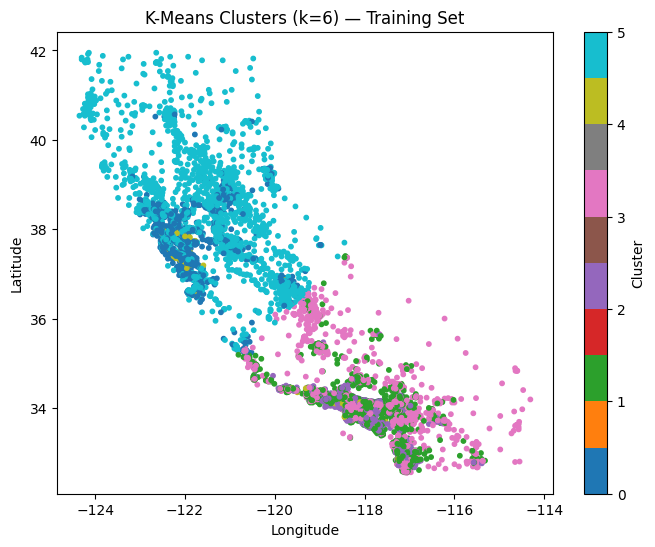

In [11]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    train_set["Longitude"],
    train_set["Latitude"],
    c=kmeans.labels_,
    cmap="tab10",
    s=10,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clusters (k=6) — Training Set")
plt.colorbar(scatter, label="Cluster")
plt.show()

### What the clusters show

The six clusters roughly map onto geographic regions of California (coastal vs inland, north vs south). `Latitude` and `Longitude` dominate the spatial layout, so neighboring census blocks tend to share a cluster. `MedInc` pulls boundaries within those regions — higher-income pockets can form or shift cluster membership even when they sit near lower-income areas on the map.

## Step 3: Predict with the Test Set

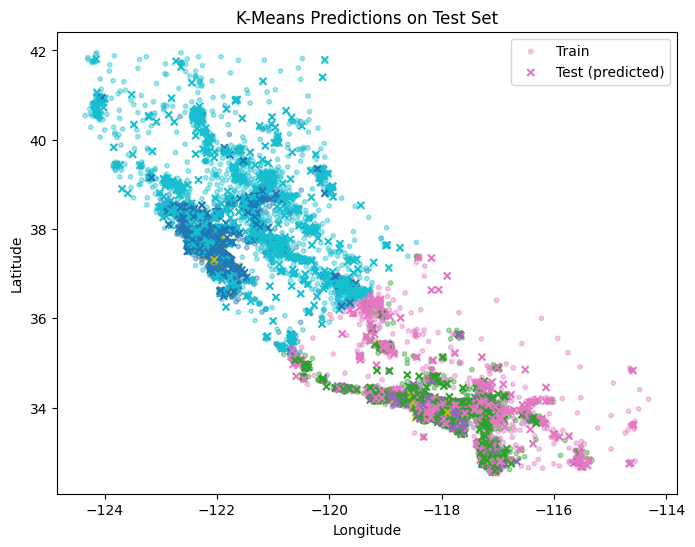

In [12]:
features = ["Latitude", "Longitude", "MedInc"]

test_set = test_set.copy()
test_set["cluster"] = kmeans.predict(test_set[features]).astype(str)

plt.figure(figsize=(8, 6))
plt.scatter(
    train_set["Longitude"],
    train_set["Latitude"],
    c=kmeans.labels_,
    cmap="tab10",
    s=10,
    alpha=0.4,
    label="Train",
)
plt.scatter(
    test_set["Longitude"],
    test_set["Latitude"],
    c=kmeans.predict(test_set[features]),
    cmap="tab10",
    s=25,
    marker="x",
    label="Test (predicted)",
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Predictions on Test Set")
plt.legend()
plt.show()

Test predictions land inside the same regional patterns as the training points — the `x` markers align with the faded train clusters rather than forming a separate structure, which confirms the fitted centroids generalize to held-out census blocks.

## Step 4: Train a Supervised Classification Model

Treat K-Means `cluster` labels as the target and train a Random Forest so new points can be classified without re-running clustering.

In [13]:
X_train = train_set[features]
y_train = train_set["cluster"]
X_test = test_set[features]
y_test = test_set["cluster"]

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9958817829457365
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       561
           1       1.00      1.00      1.00       983
           2       0.99      1.00      0.99       299
           3       1.00      1.00      1.00      1111
           4       0.98      0.97      0.98        62
           5       1.00      0.99      1.00      1112

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



### Classification results

Accuracy is about **99.6%** — the Random Forest closely reproduces the K-Means decision regions from the same three features. Most clusters score near-perfect precision/recall. **Cluster 4** is the weakest (fewest samples, slightly lower precision/recall): it sits on a thinner geographic/income boundary, so a handful of edge points get confused with neighboring clusters.

## Step 5: Save the Models

In [14]:
os.makedirs("../models", exist_ok=True)

with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("../models/classifier_model.pkl", "wb") as f:
    pickle.dump(clf, f)

print("Saved models/kmeans_model.pkl and models/classifier_model.pkl")

Saved models/kmeans_model.pkl and models/classifier_model.pkl
